<a href="https://colab.research.google.com/github/Dennisogaka/Feature-Engineering/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Objective - handling missing data.
- Detect and quantify missing data patterns in a dataset.
- Choose the right strategy for differnt types of missingness.
- Implement imputation using sklearn SimpleImputer and KNNImputer.


#Handling Missing Data.
##Why is Data Missing? - Understanding Missingness Mechanism.
#1. MCAR - Missing Completely At Random.
- Missingness has no pattern e.g Sensor Glitch.
###Strategy
- Drop rows (if small %)
- Simple imputation with mean/median.

Missingness does not bias the dataset, hence it is safe.

#2. MAR - Missing At Random
- Missing depends on other observed features. E.g older patients less likely to report income.
###Strategy
- Use models that leverage relationships.(Imputation using related features)
      - KNN Imputer.
      - Regression Based Imputer.
- Because other features contain useful clues.

#3. MNAR - Missing Not At Random
- Missingness is related to the missing value itself.
- The missingness depends on unobserved information, making it systematic rather than random.
- "Most problem - Create an 'is missing' flag feature"

##Handling MNAR Data:
- Sensitivity Analysis: Testing how different assumptions about missing data affect results.
- Modelling - Using advanced models that explicitly model the missing mechanisms.
- Auxillary Data - Incorporating additional variables that might correlate with the missing value.




In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
print("Missing Values per Column")
df.isnull().sum()

Missing Values per Column


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.isnull().mean()*100.round(1)

SyntaxError: invalid decimal literal (473230562.py, line 1)

In [12]:
print("Percentage Missing Values per Column")
(df.isnull().mean() * 100).round(1)

Percentage Missing Values per Column


,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,19.9
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


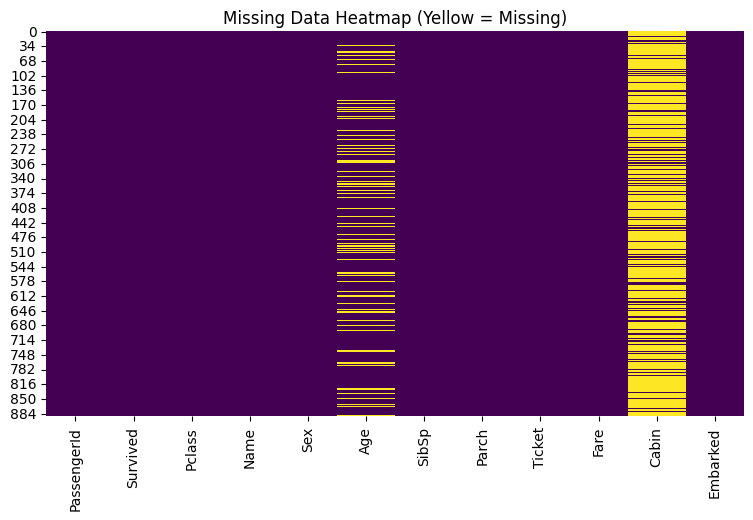

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Yellow = Missing)')
plt.show()

In [16]:
missing_df = pd.DataFrame({
    'missing count' : df.isnull().sum(),
    'missing percentage' : (df.isnull().mean()*100).round(1)
})

print(missing_df[missing_df['missing count']>0].sort_values(
    "missing percentage", ascending=False))

          missing count  missing percentage
Cabin               687                77.1
Age                 177                19.9
Embarked              2                 0.2


In [17]:
# Drop rows or columns - We drop data when it is safe or useless.

df_clean=df.drop(columns=['Cabin'])

In [18]:
df_clean=df_clean.dropna(subset=['Embarked'])
print('After Dropping',df_clean.shape)
print('Missing in Age', df_clean['Age'].isnull().sum())

After Dropping (889, 11)
Missing in Age 177


In [20]:
#Strategy 2: Simple Imputation
##Numeric Median

from sklearn.impute import SimpleImputer
age_imputer=SimpleImputer(strategy="median")
df_clean['Age'] = age_imputer.fit_transform(df_clean[['Age']])

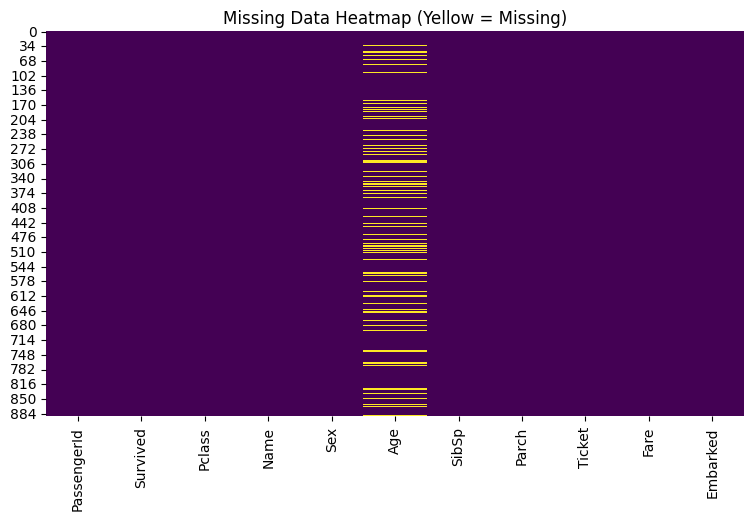

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.heatmap(df_clean2.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Yellow = Missing)')
plt.show()

In [ ]:
#How to fill Categorical Features
#Categorical - We are going to fill in using most frequent.

In [24]:
df_clean2 = df.drop(columns=['Cabin'])

In [25]:
emb_imputer = SimpleImputer(strategy='most_frequent')
df_clean2['Embarked'] = emb_imputer.fit_transform(df_clean2[['Embarked']]).ravel()

In [27]:
df_clean.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
#Strategy 3: KNN Imputation
##Smarter method that looks at similar rows.
##Works on numerical data only

from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
numeric_columns = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

df_knn = df[numeric_columns].copy()

df_filled = pd.DataFrame(knn_imputer.fit_transform(df_knn), columns=numeric_columns)

df_filled.isnull().sum()

,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
